# VM Allocation Optimization Benckmark

### BENCHMARK PURPOSE :

The purpose of this benchmark is to generate large-scale synthetic datasets in order to evaluate and compare the computational performance of different VM allocation solvers. Specifically, we aim to measure and analyze the execution time, scalability, and solution quality of three approaches: First Fit Decreasing (FFD), Mixed Integer Linear Programming (PLNE/MILP), and CP-SAT constraint programming. By applying these solvers to identical problem instances of increasing size and complexity, we can assess their efficiency under realistic constraints such as capacity limits, affinity/anti-affinity rules, and resource fragmentation. The goal is to identify the trade-offs between speed and optimality, and to determine which solver provides the best balance for large-scale infrastructure allocation problems.

In [27]:
# imports

import random
from time import perf_counter
from vm_allocation.datasets.utils import fragmentation_percentage
from vm_allocation.models import Server, VM, Context, Solver
from vm_allocation.datasets.generate_dataset import generate_vm, generate_n_servers
from vm_allocation.solvers import FFDSolver, PLNESolver, CPSATSolver
import importlib
import vm_allocation.datasets.generate_dataset
from vm_allocation.datasets.generate_dataset import generate_n_vms_with_context


## Problem initialization

In [28]:
#we create a context with n servers and n VMs, then we plot the context
servers_number = 12
vms_number = 60

all_servers = generate_n_servers(servers_number)
context = Context(all_servers)

vms, random_context = generate_n_vms_with_context(vms_number, context)

#we print affinity and anti-affinity rules

Affinity added with vm : 4
antiffinity added with vm : 7
antiffinity added with vm : 8
antiffinity added with vm : 1
Affinity added with vm : 12
Affinity added with vm : 5
antiffinity added with vm : 13
Affinity added with vm : 16
Affinity added with vm : 6
Affinity added with vm : 11
antiffinity added with vm : 23
antiffinity added with vm : 26
antiffinity added with vm : 18
antiffinity added with vm : 8
Affinity added with vm : 9
antiffinity added with vm : 21
antiffinity added with vm : 37
Affinity added with vm : 23
Affinity added with vm : 32
antiffinity added with vm : 28
antiffinity added with vm : 0
antiffinity added with vm : 11
antiffinity added with vm : 27
antiffinity added with vm : 11
antiffinity added with vm : 29
antiffinity added with vm : 33
antiffinity added with vm : 32
Affinity added with vm : 11
antiffinity added with vm : 23
Affinity added with vm : 45
Affinity added with vm : 44
antiffinity added with vm : 9
antiffinity added with vm : 30


# VISUAL FOR RANDOM CONTEXT

VMs number: 60


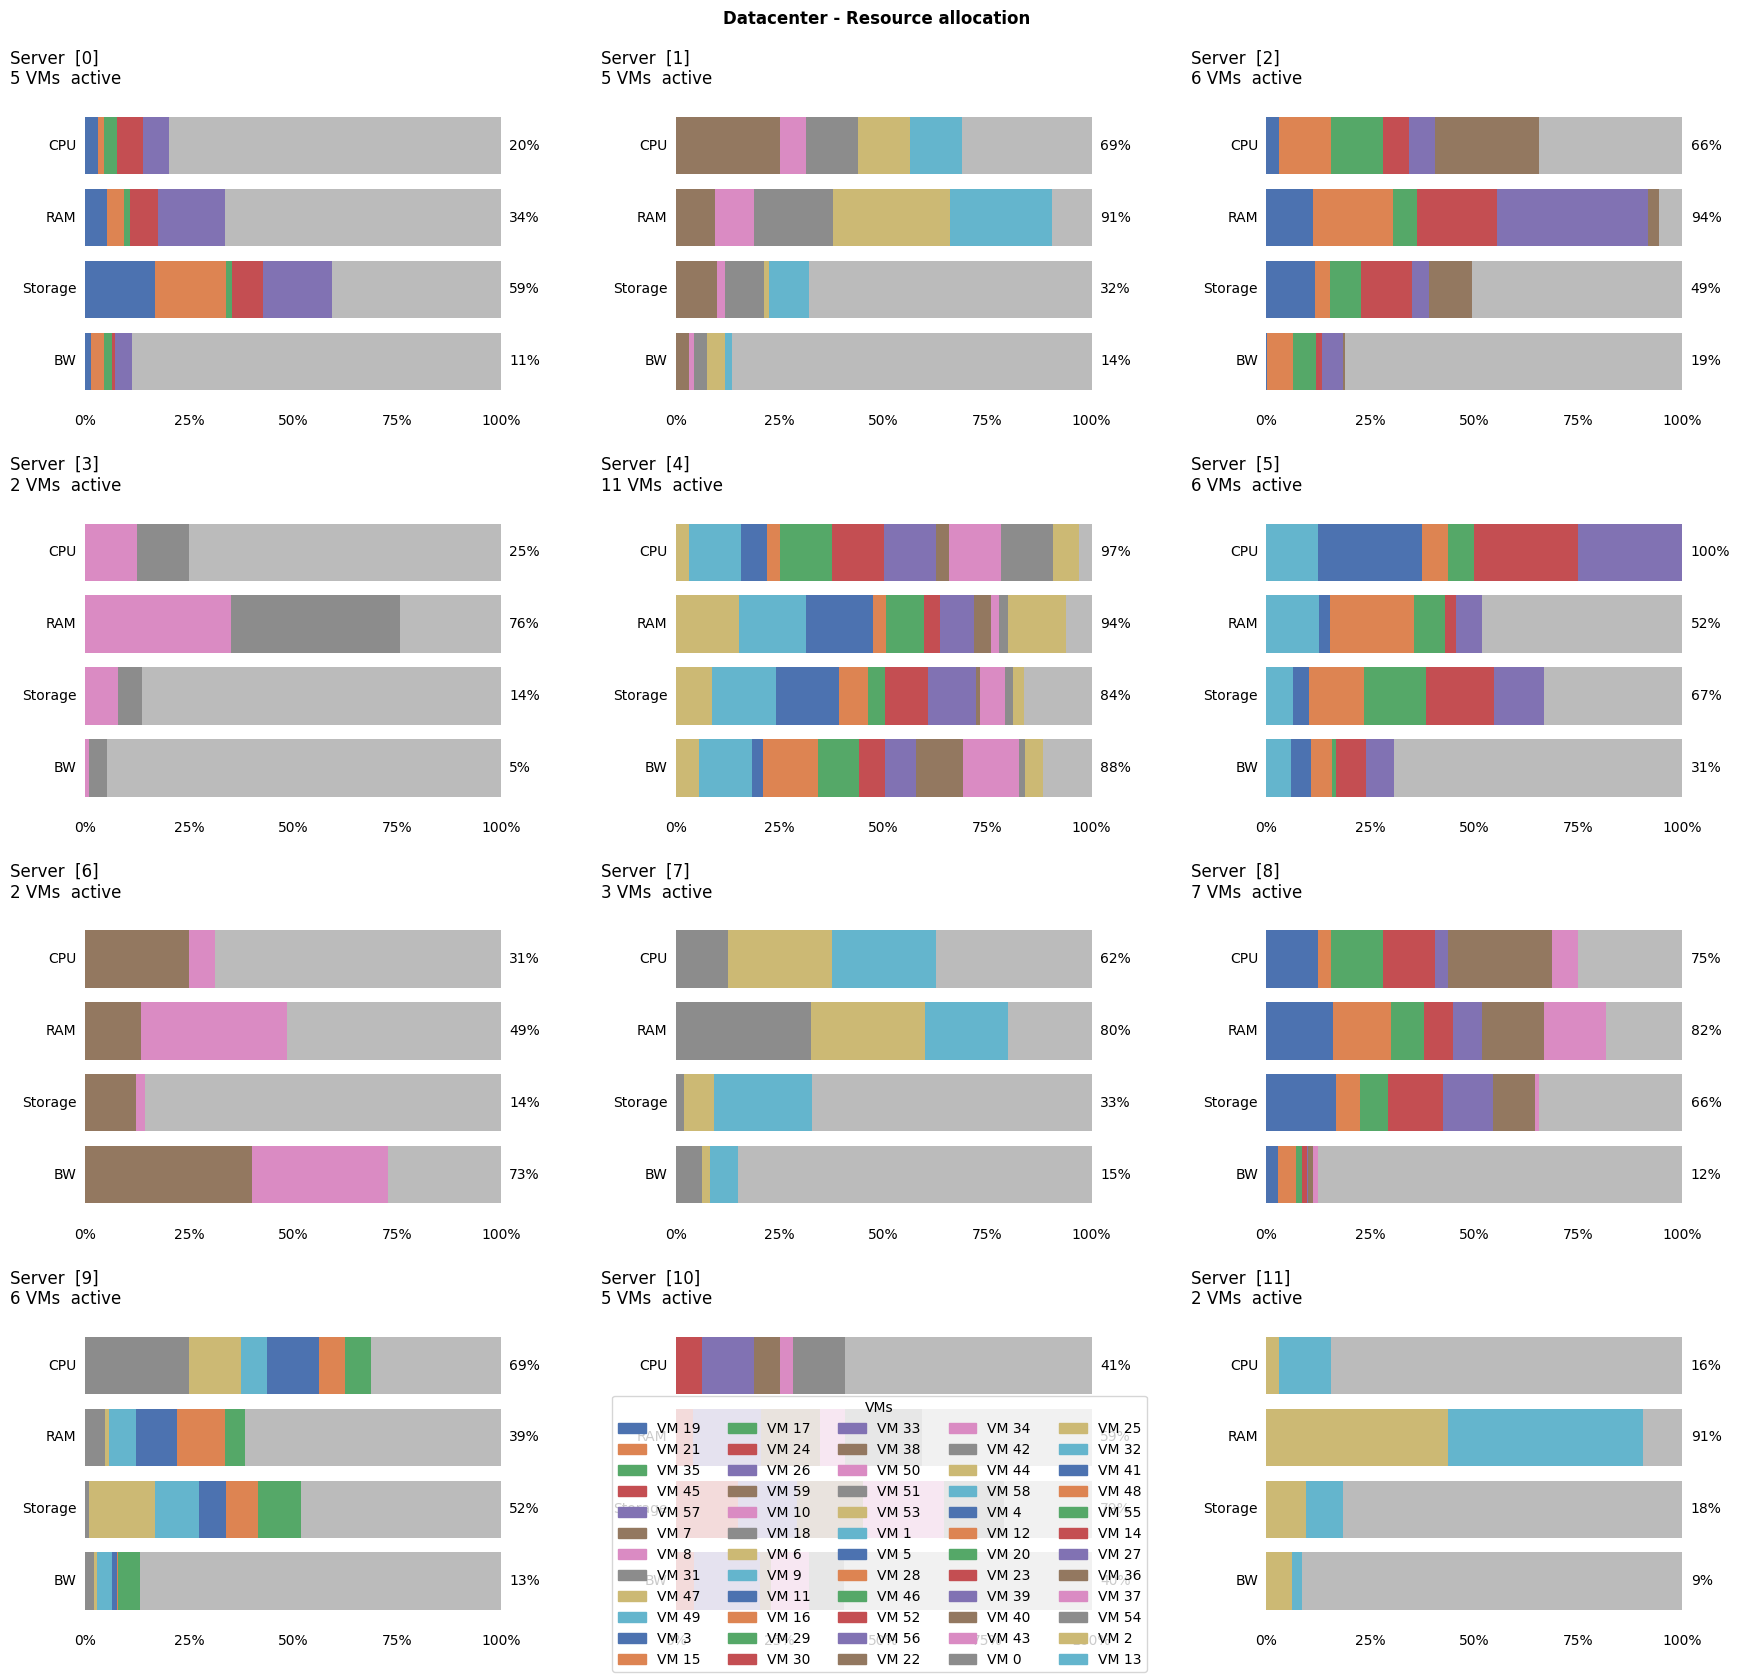

In [29]:
print("VMs number:", len(vms))

fig = random_context.plot()
fig

# Solver initialization and dataset duplication

In [30]:

# FDD
fdd = FFDSolver()
context_for_FDD = context.copy()
new_vms_for_FDD = [vm.copy() for vm in vms]

# PLNE
plne = PLNESolver()
context_for_PLNE = context.copy()
new_vms_for_PLNE = [vm.copy() for vm in vms]

# CPSAT
cpsat = CPSATSolver(migration_weight=0.5, fragmentation_weight=0.5)
context_for_CPSAT = context.copy()
new_vms_for_CPSAT = [vm.copy() for vm in vms]


# SPEED TEST

In [31]:
# FDD
start = perf_counter()
solution_context_fdd = fdd.solve(new_vms_for_FDD, context_for_FDD)
end = perf_counter()
fdd_time = end - start

# PLNE
start = perf_counter()
solution_context_plne = plne.solve(new_vms_for_PLNE, context_for_PLNE)
end = perf_counter()    
plne_time = end - start

# CPSAT
start = perf_counter()
solution_context_cpsat = cpsat.solve(new_vms_for_CPSAT, context_for_CPSAT)
end = perf_counter()
cpsat_time = end - start

#print the results
print(f"FDD time: {fdd_time:.4f} seconds")
print(f"PLNE time: {plne_time:.4f} seconds")
print(f"CPSAT time: {cpsat_time:.4f} seconds")


FDD time: 0.0004 seconds
PLNE time: 1.4460 seconds
CPSAT time: 4.9947 seconds


# Visuals for context solutions

## FDD

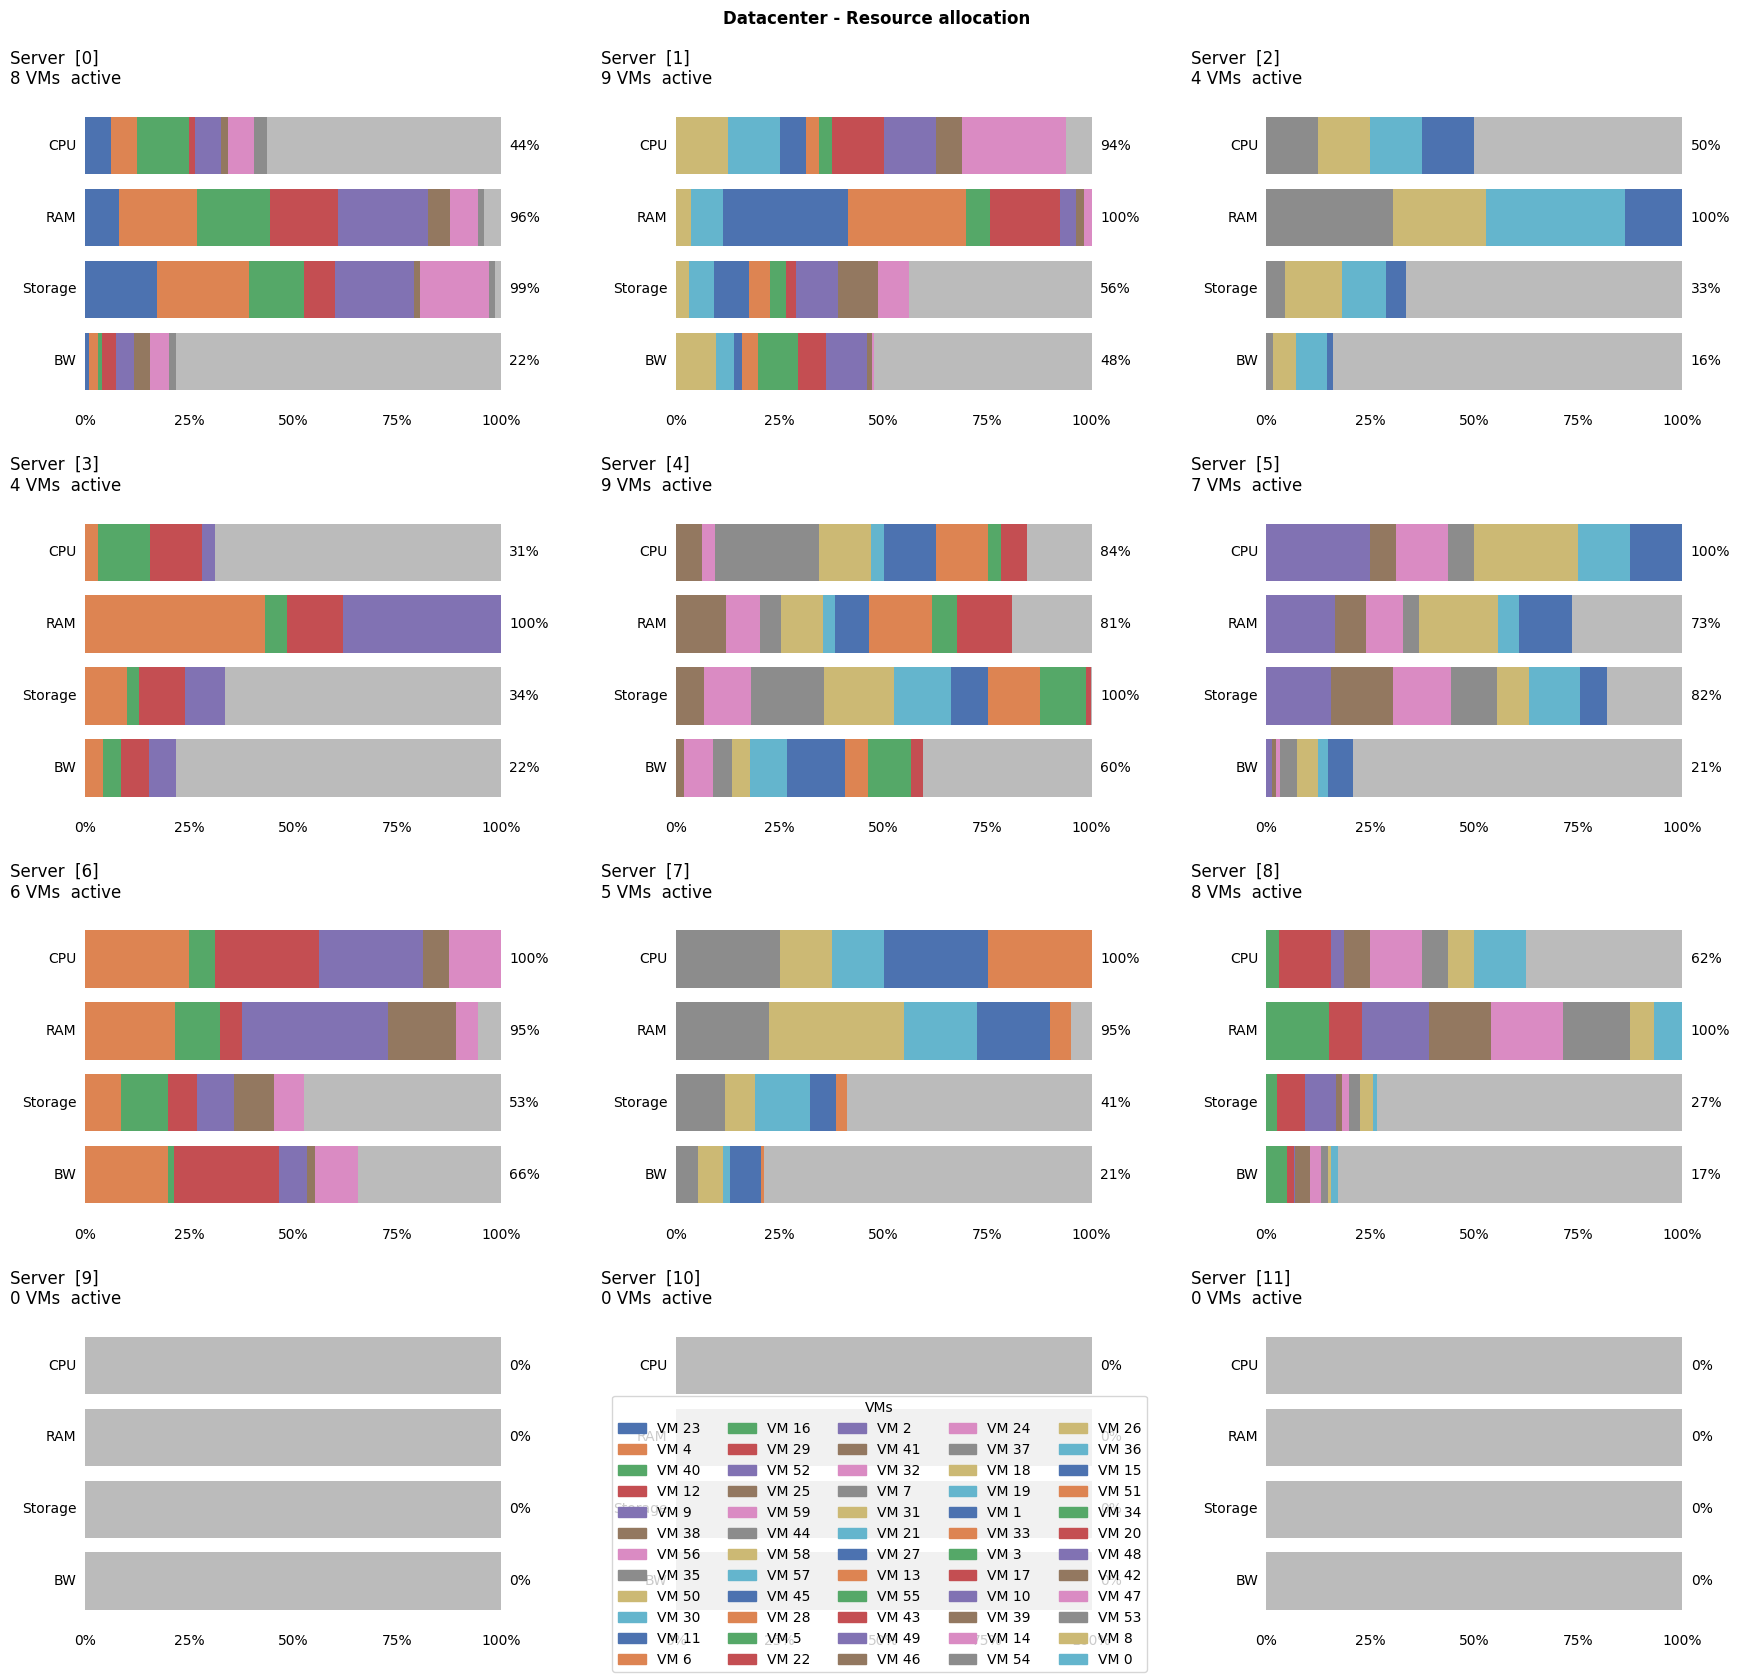

In [32]:
fig = solution_context_fdd.plot()
fig

## CP-SAT

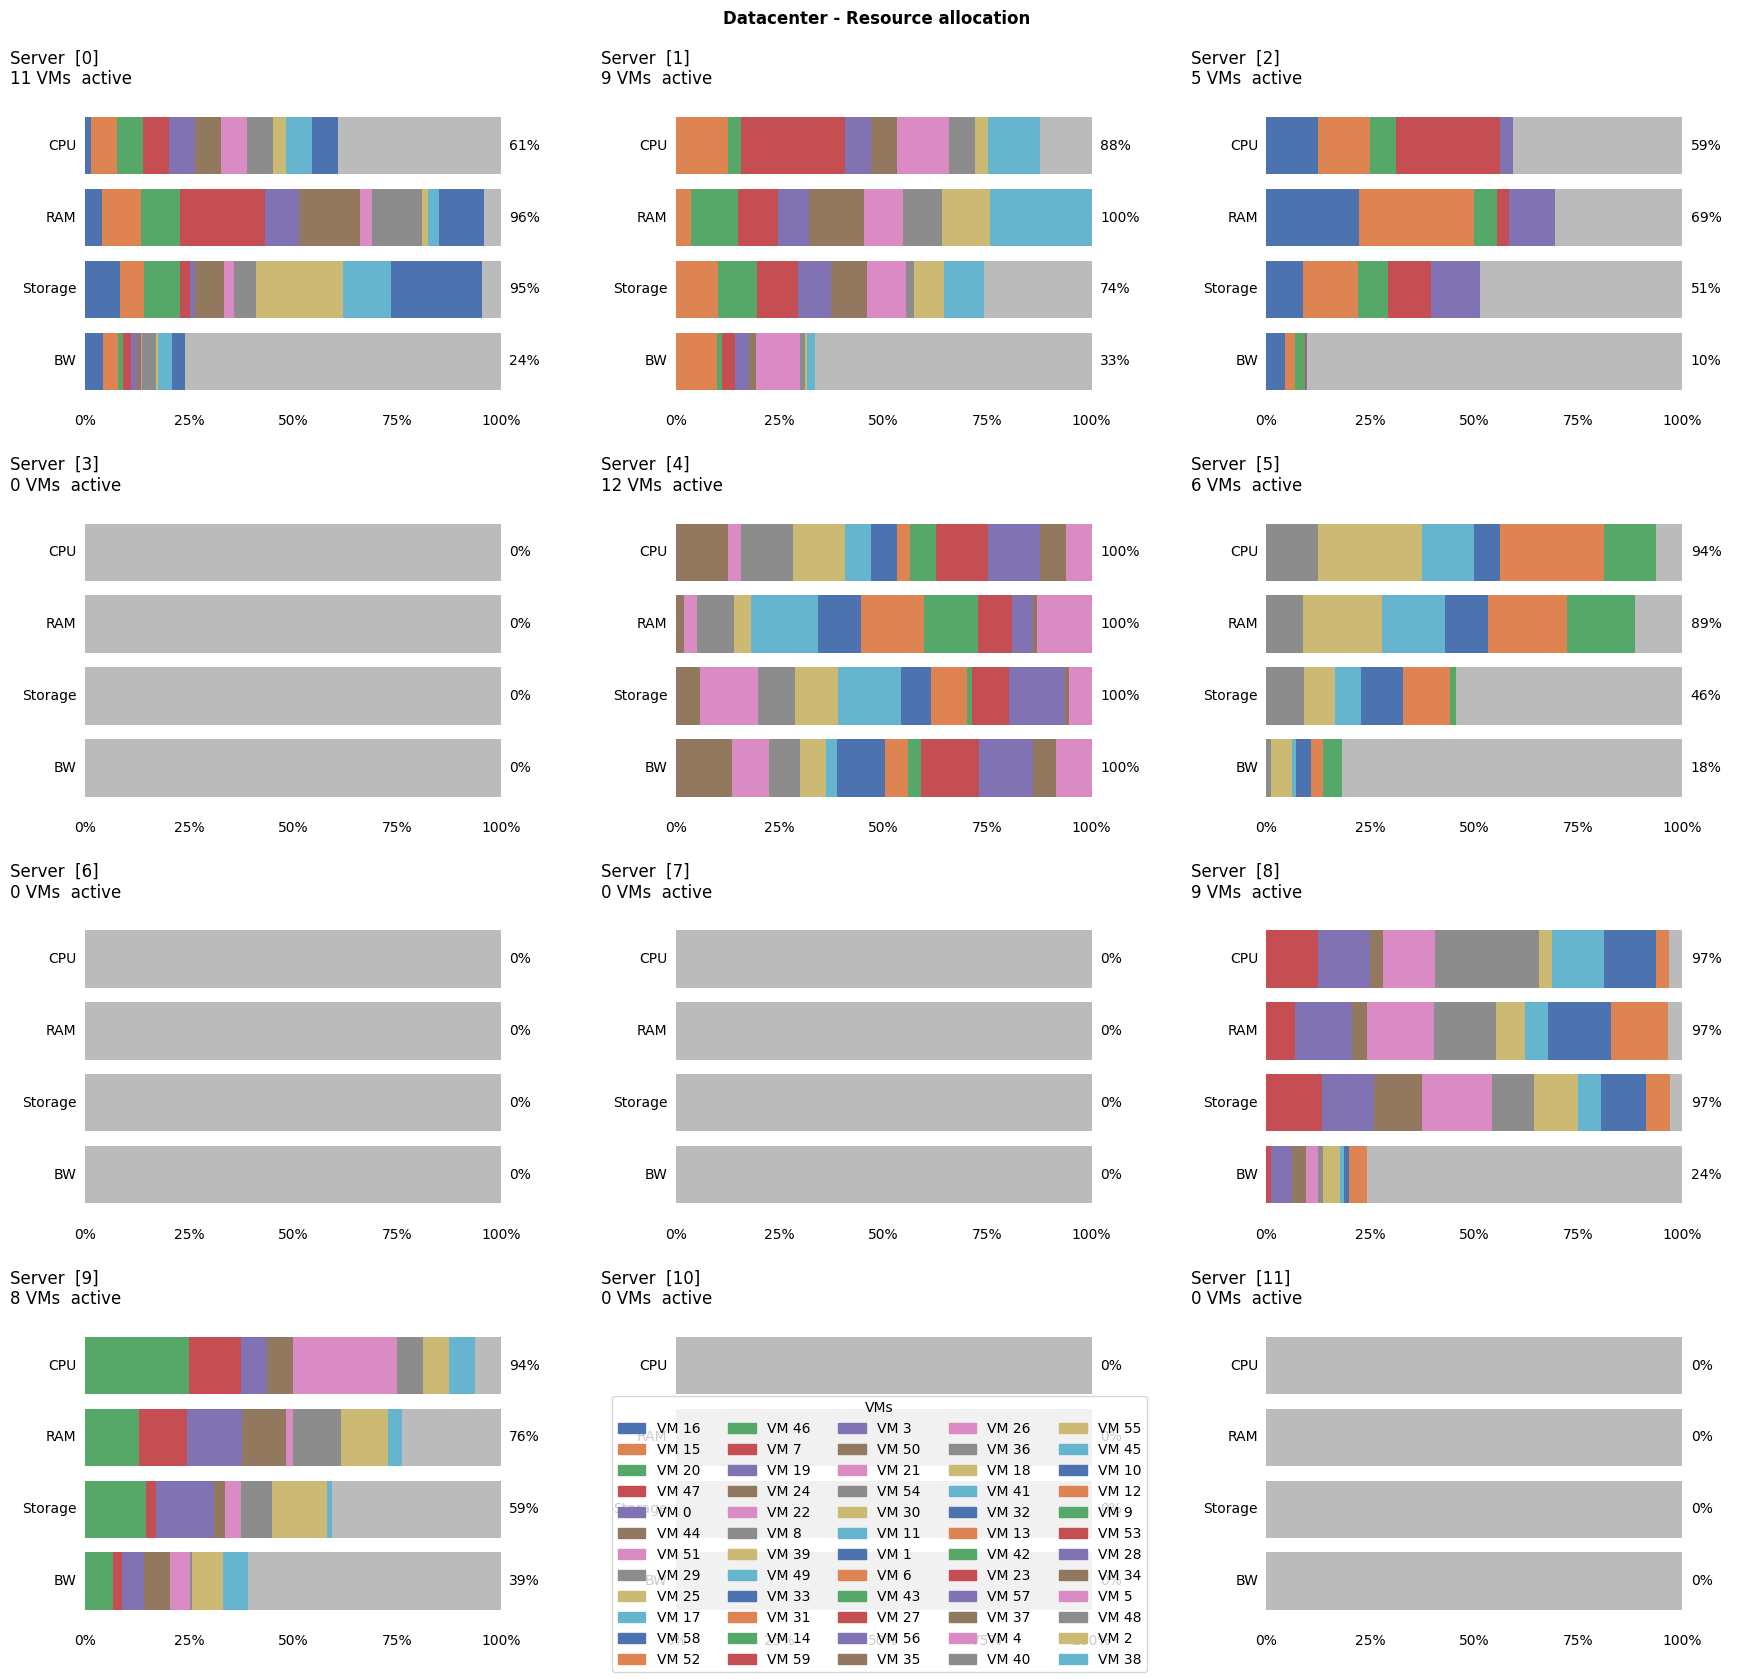

In [33]:
fig = solution_context_cpsat.plot()
fig



## PLNE

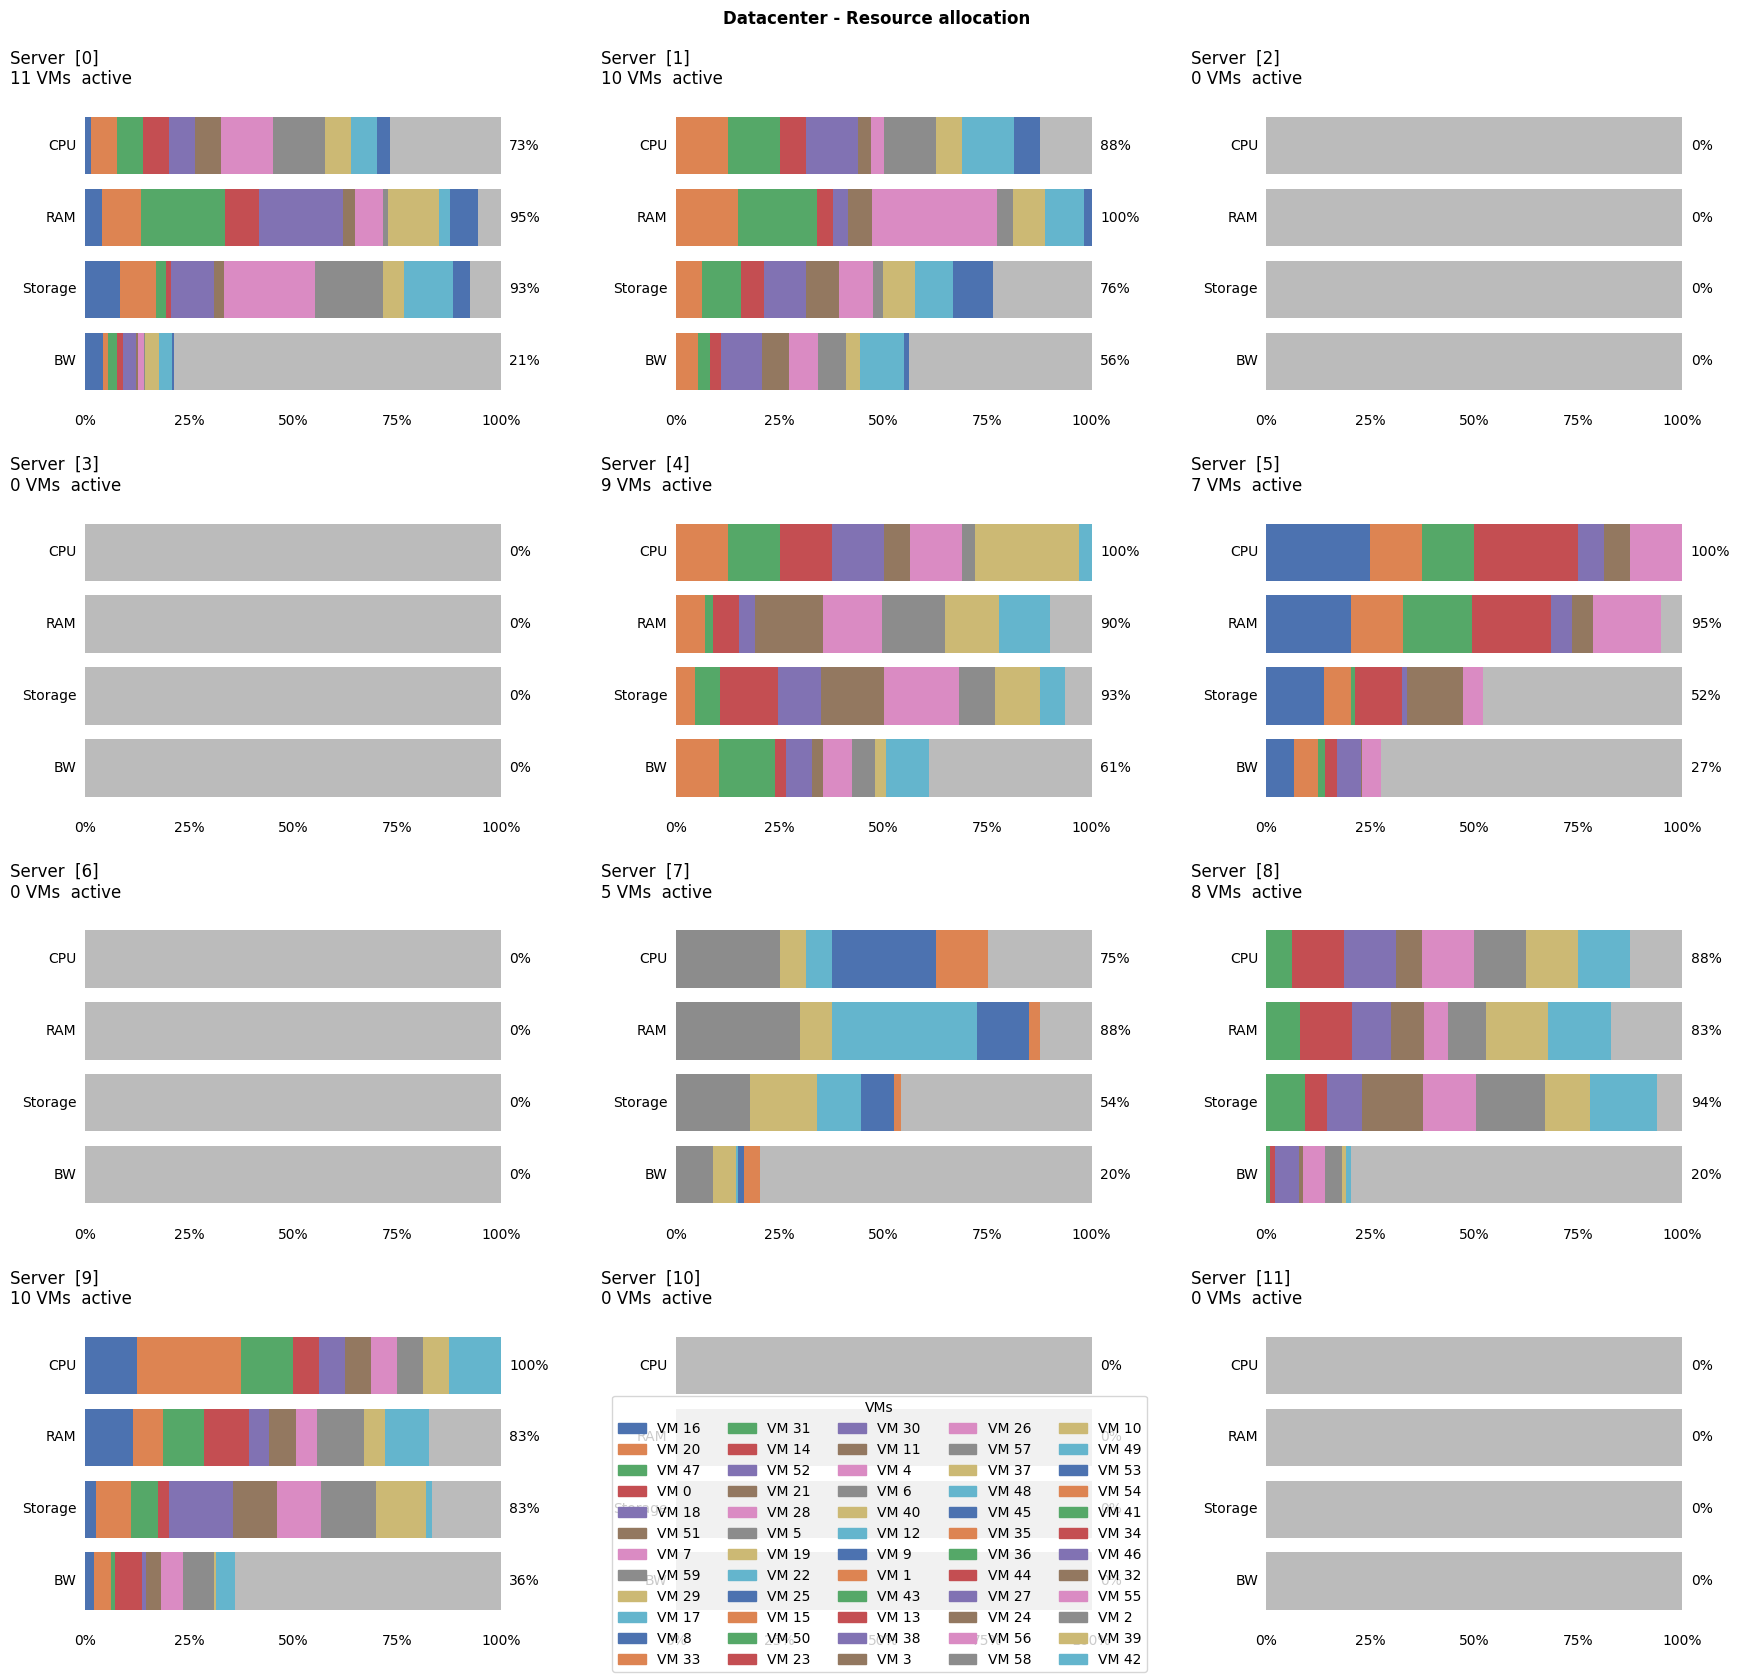

In [34]:
fig = solution_context_plne.plot()
fig


# INTERPRETATION OF THE RESULTS

First Fit Decreasing (FFD), Mixed Integer Linear Programming (MILP/PLNE), and CP-SAT solvers exhibit very different performance characteristics in virtual machine allocation problems. FFD is a heuristic approach designed for speed and scalability; it produces solutions almost instantly even for large datasets, but the solutions are not always optimal and may lead to higher resource fragmentation. In contrast, MILP solvers aim to find mathematically optimal solutions by exploring a large combinatorial search space, which often results in significantly higher computation times as the problem size and number of constraints increase. CP-SAT represents a modern compromise between these two approaches: it combines constraint programming, SAT solving, and optimization techniques to achieve near-optimal or optimal solutions while remaining substantially faster and more scalable than traditional MILP formulations. In practice, FFD is usually the fastest method, MILP the slowest but most exact, and CP-SAT offers the best balance between execution time and solution quality for complex VM allocation scenarios involving affinity, anti-affinity, and capacity constraints.

# FRAGMENTATION BENCHMARCK

In [36]:
print("Fragmentation percentage and number of servers used for each algorithm: (lower is better)\n\n")

(fragmentation, server_used) = fragmentation_percentage(solution_context_fdd)
fragmentation = round(fragmentation, 2)
server_used = round(server_used, 2)
print(f"Fragmentation percentage for FDD: {fragmentation}%")
print(f"Number of servers used for FDD: {server_used}%\n")

(fragmentation, server_used) = fragmentation_percentage(solution_context_plne)
fragmentation = round(fragmentation, 2)
server_used = round(server_used, 2)
print(f"Fragmentation percentage for PLNE: {fragmentation}%")
print(f"Number of servers used for PLNE: {server_used}%\n")

(fragmentation, server_used) = fragmentation_percentage(solution_context_cpsat)
fragmentation = round(fragmentation, 2)
server_used = round(server_used, 2)
print(f"Fragmentation percentage for CPSAT: {fragmentation}%")
print(f"Number of servers used for CPSAT: {server_used}%")

Fragmentation percentage and number of servers used for each algorithm: (lower is better)


Fragmentation percentage for FDD: 74.82%
Number of servers used for FDD: 75.0%

Fragmentation percentage for PLNE: 55.82%
Number of servers used for PLNE: 58.33%

Fragmentation percentage for CPSAT: 44.9%
Number of servers used for CPSAT: 58.33%


# INTERPRETATION

# CONCLUSION

The results show that both PLNE and CPSAT perform better than the FDD heuristic in terms of resource allocation quality. FDD produces a more scattered allocation with higher fragmentation and uses a larger number of servers, which indicates less efficient consolidation of virtual machines. In contrast, PLNE and CPSAT achieve a more balanced allocation with lower fragmentation and fewer active servers, meaning they manage to pack virtual machines more efficiently and make better use of the available resources. Overall, the optimization-based approaches provide more effective and compact solutions compared to the greedy heuristic.


The results highlight a clear trade-off between speed and solution quality among the three approaches. The FDD heuristic is extremely fast, making it suitable for real-time or large-scale scenarios where quick decisions are needed, but this comes at the cost of less efficient resource allocation. In contrast, PLNE and CPSAT require significantly more computation time due to their optimization-based nature, but they produce higher-quality solutions with better resource utilization and lower fragmentation. Overall, heuristic methods favor speed, while exact or constraint-based solvers favor solution quality.
